In [1]:
import keras
import keras_nlp
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from keras.saving import load_model
from tensorflow.keras.utils import plot_model
from helper import init_resource_dicts, get_arrays, get_strings

from matplotlib.ticker import ScalarFormatter

feat_file = "./Feature_files/featsNew"
symbol2feats, suffix2label, label2suffix = init_resource_dicts(feat_file)

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / exp_x.sum(axis=-1, keepdims=True)

In [58]:
feature_names = ["cons", "syll", "son", "approx", "voice", "cont", "nas", "strid", "lab", "cor", "and", 
                 "dist", "dor", "high", "back", "tense", "diph", "stress", "main"]

def get_saliency_maps(grads_dict, titles):
    
    num_features = len(feature_names)
    time_steps = grads_dict[next(iter(grads_dict))].shape[1]  # Assume all classes have the same shape
    box_size = 0.5  # Adjust box size as needed
    fig_width = box_size * num_features
    fig_height = box_size * time_steps * len(grads_dict)
    
    fig, axes = plt.subplots(len(grads_dict), 1, figsize=(fig_width, fig_height), constrained_layout=True)
    fig.subplots_adjust(hspace=1)
    # fig, axes = plt.subplots(len(grads_dict), 1, figsize=(8, len(grads_dict) * 4), constrained_layout=True)
    # fig.subplots_adjust(hspace=0.5)
    
    for i, (cls, grads) in enumerate(grads_dict.items()):
        ax = axes[i]
        im = ax.imshow(grads[0], cmap="viridis", aspect="equal")  # Use "auto" for better scaling
        ax.set_title(titles[i], pad=15)
        ax.set_xlabel("Phonological Features", labelpad=1)
        ax.set_ylabel("Time Steps")
        ax.set_xticks(np.arange(len(feature_names)))
        ax.set_xticklabels(feature_names, rotation=60, ha="right")
        
        # Add colorbar with scientific notation
        cbar = fig.colorbar(im, ax=ax, orientation="vertical", format=ScalarFormatter())
        cbar.ax.tick_params(labelsize=8)
        
        cbar.formatter.set_scientific(True)
        cbar.formatter.set_powerlimits((0, 0))
        cbar.update_ticks()
    
    plt.show()

def compute_avg_gradients_by_class(X, Y, model):
    # Unique classes
    unique_classes = np.unique(np.argmax(Y, axis=1))
    print(unique_classes)
    
    # Store average gradients for each class
    class_avg_gradients = {}
    
    for cls in unique_classes:
        # Select inputs for this class
        class_mask = np.argmax(Y, axis=1) == cls
        class_inputs = X[class_mask]
        
        # Compute gradients for each input in the class
        class_gradients = []
        for input_data in class_inputs:
            batched_input = tf.expand_dims(input_data, axis=0)
            
            with tf.GradientTape() as tape:
                tape.watch(batched_input)
                predictions = model(batched_input)
                output = predictions[0, cls]
            
            grad = tape.gradient(output, batched_input)
            class_gradients.append(grad.numpy())
        
        # Average gradients for this class
        class_avg_gradients[cls] = np.mean(class_gradients, axis=0)
    
    return class_avg_gradients

URs, SRs, Ls = get_strings("EqualDefault/equalFreq_test.txt")
X, Y = get_arrays(URs, SRs, Ls, symbol2feats, suffix2label, override_max_syll=5)
Y = tf.keras.utils.to_categorical(Y, num_classes = 3)

[0 1 2]


/var/folders/rb/f9l8vst90398j4kc8w_y8h6h0000gn/T/ipykernel_1921/2743047482.py:13: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=1)


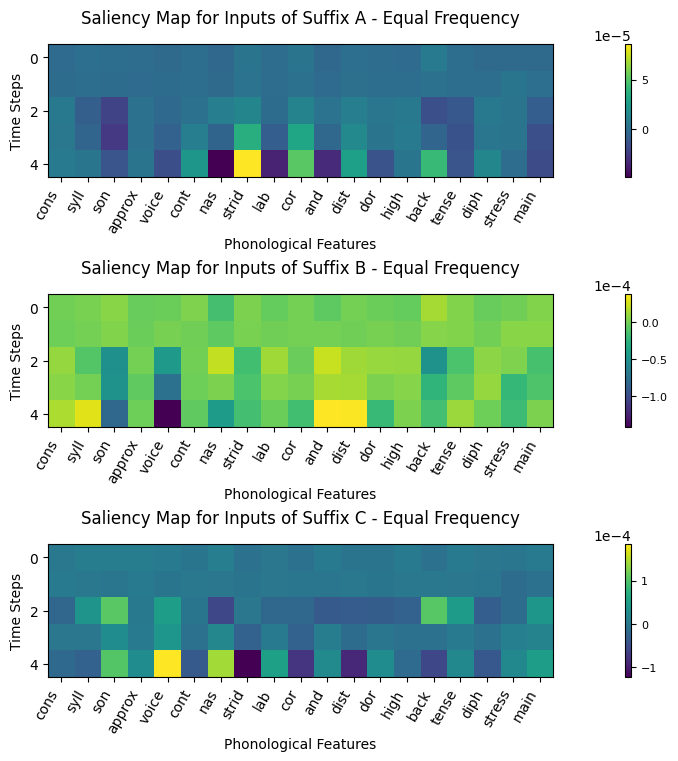

In [59]:
load_filepath = f"./Models/Transformer_Results_batch32_latent64/equalFreq_model_0.keras"
# load_filepath = f"./Models/lstm_rep9_equalFreq.keras"

model = load_model(load_filepath)

gradient_dict = compute_avg_gradients_by_class(X, Y, model)

titles = [
    "Saliency Map for Inputs of Suffix A - Equal Frequency",
    "Saliency Map for Inputs of Suffix B - Equal Frequency",
    "Saliency Map for Inputs of Suffix C - Equal Frequency"
]

get_saliency_maps(gradient_dict, titles)

[0 1 2]


/var/folders/rb/f9l8vst90398j4kc8w_y8h6h0000gn/T/ipykernel_1921/2743047482.py:13: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=1)


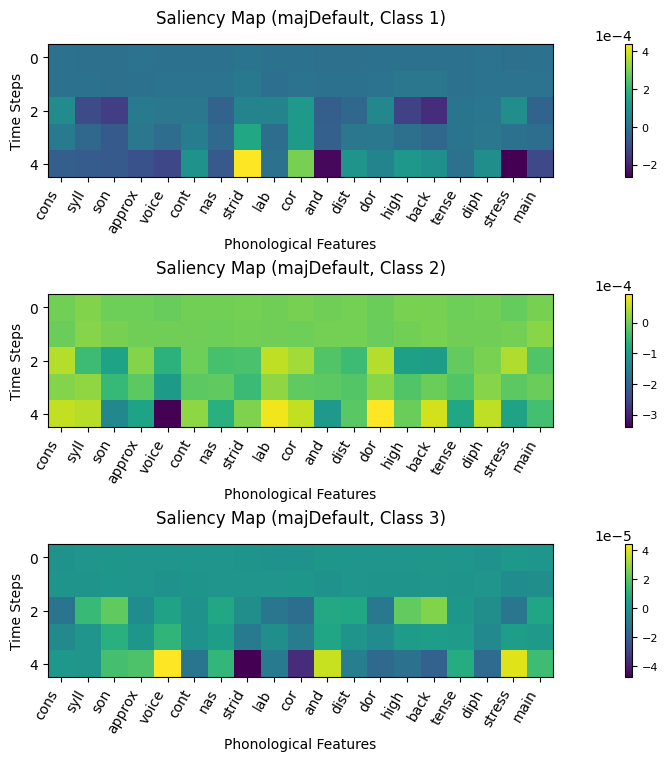

In [60]:
load_filepath = f"./Models/Transformer_Results_batch32_latent64/majDefault_model_0.keras"
model = load_model(load_filepath)
gradient_dict = compute_avg_gradients_by_class(X, Y, model)

titles = [
    "Saliency Map (majDefault, Class 1)",
    "Saliency Map (majDefault, Class 2)",
    "Saliency Map (majDefault, Class 3)"
]

get_saliency_maps(gradient_dict, titles)

[0 1 2]


/var/folders/rb/f9l8vst90398j4kc8w_y8h6h0000gn/T/ipykernel_1921/2743047482.py:13: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=1)


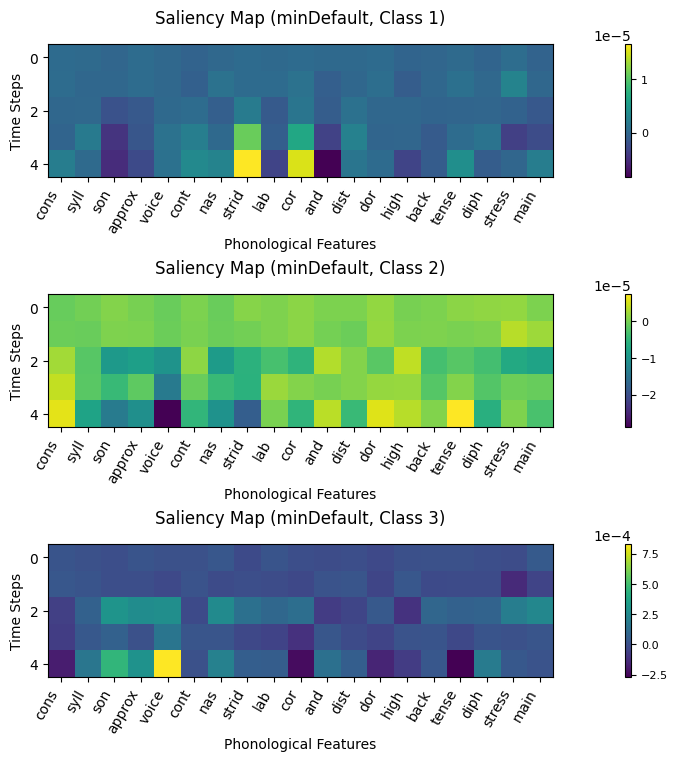

In [61]:
load_filepath = f"./Models/Transformer_Results_batch32_latent64/minDefault_model_0.keras"
model = load_model(load_filepath)
gradient_dict = compute_avg_gradients_by_class(X, Y, model)

titles = [
    "Saliency Map (minDefault, Class 1)",
    "Saliency Map (minDefault, Class 2)",
    "Saliency Map (minDefault, Class 3)"
]

get_saliency_maps(gradient_dict, titles)

In [62]:
# dummy_input = tf.expand_dims(X[7], axis=0)  # Add batch dimension, Batch size = 1, Sequence length = 5, Features = 19
# dummy_input = tf.convert_to_tensor(dummy_input) 
# # print(dummy_input.shape) # (1, 5, 19)

# # Create a model
# model = load_model(load_filepath)

# for i in range(3):
# 	# Compute gradients with tf.GradientTape
# 	with tf.GradientTape() as tape:
# 		tape.watch(dummy_input)  # Watch the input for gradient computation
# 		predictions = model(dummy_input)  # Forward pass
# 		print(predictions.shape)
# 		print(f"Predictions: {softmax(predictions)}")
# 		output = predictions[:, i]  # Choose the first class for gradients

# 	# Compute gradients of the output w.r.t. the input
# 	grads = tape.gradient(output, dummy_input)

# 	# Visualize the gradients
# 	plt.imshow(grads[0], cmap="viridis")
# 	plt.title(f"Saliency Map for output class {i+1} (gold class 3)")
# 	plt.xlabel("Features")
# 	plt.ylabel("Time Steps")
# 	plt.xticks(ticks=np.arange(len(feature_names)), labels=feature_names, rotation=60, ha="right")
# 	plt.colorbar()
# 	plt.show()